In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# import shutil

# shutil.rmtree('data/')

In [ ]:
%pip install torchmetrics

In [ ]:
%pip install segmentation_models_pytorch

In [ ]:
# ML/Data handling imports
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score

import os
import glob

In [ ]:
# ========================================
# CONFIGURATION
# ========================================

# Path to the tile directory
tile_dir = "drive/MyDrive/Ocean_Hackathon/tiles"
# Path to the vector labels
vector_path = "drive/MyDrive/Ocean_Hackathon/N_Sentier_du_Littoral_L_Finistere_3857.gpkg"

TILE_SIZE = 4096
TARGET_SIZE = 1024
BATCH_SIZE = 2

In [ ]:
# ========================================
# STEP 4: VERIFY TILES
# ========================================
print("\nVerifying generated tiles...")
img_files = sorted(glob.glob(os.path.join(tile_dir, "*_img_*.npy")))
mask_files = sorted(glob.glob(os.path.join(tile_dir, "*_mask_*.npy")))
print(f"Found {len(img_files)} image tiles and {len(mask_files)} mask tiles")


Verifying generated tiles...
Found 476 image tiles and 476 mask tiles



Visualizing sample tiles from each TIFF...


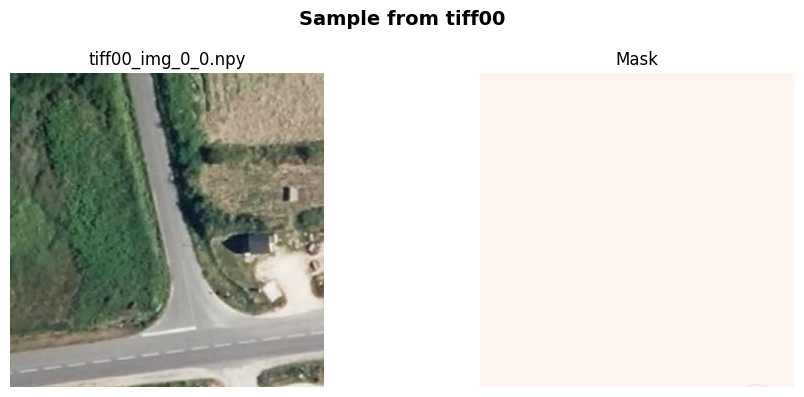

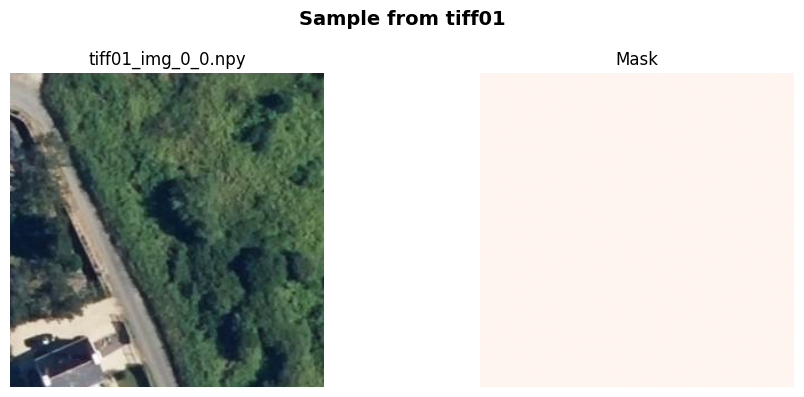

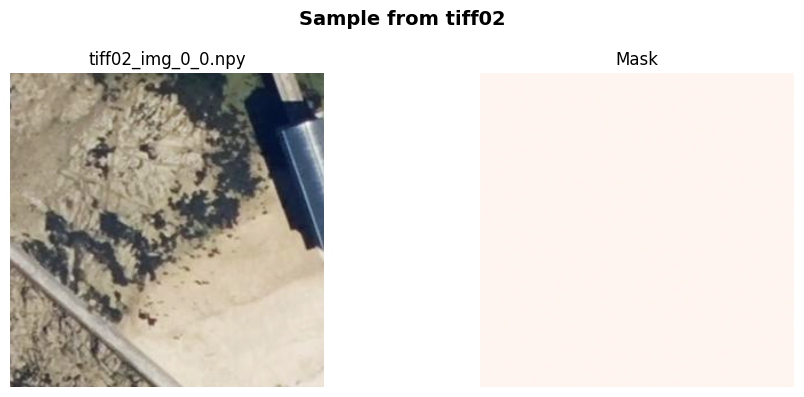

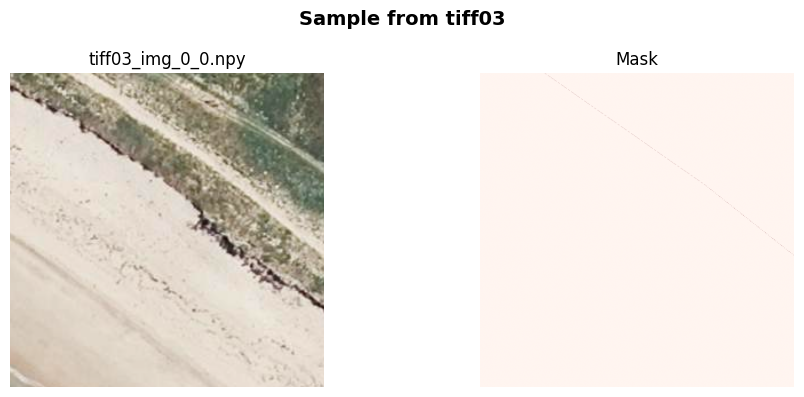

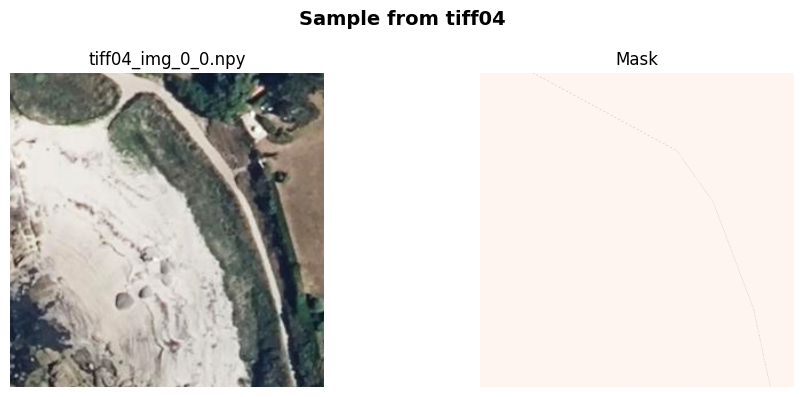

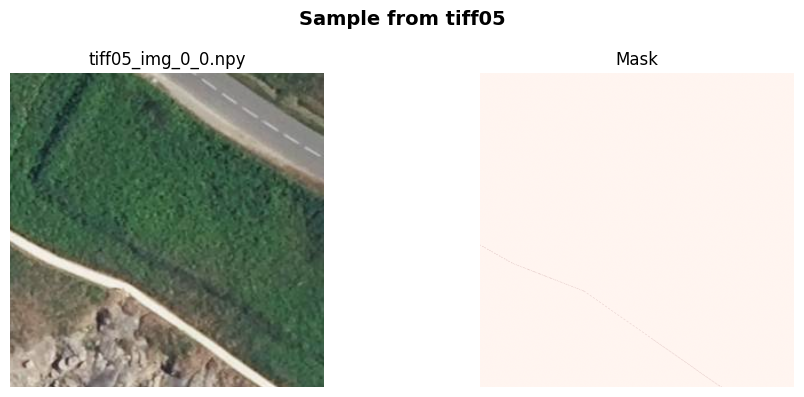

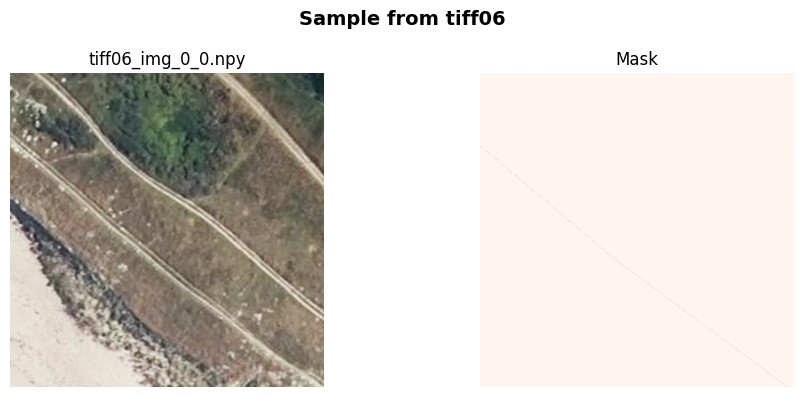

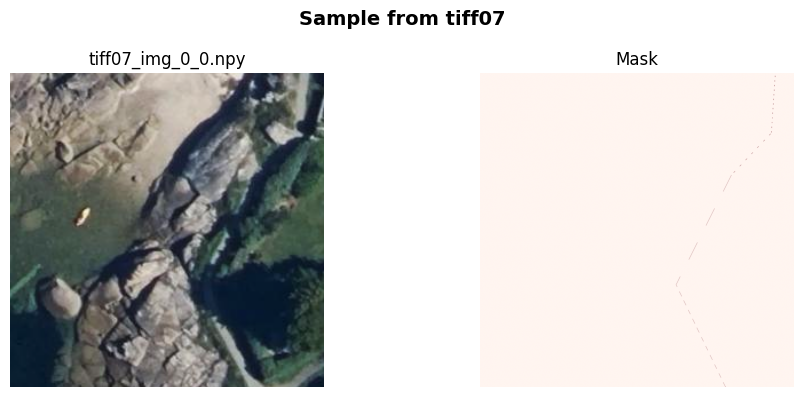

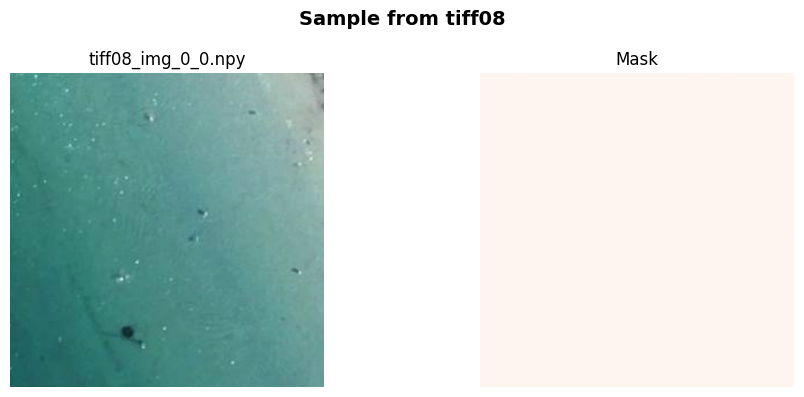

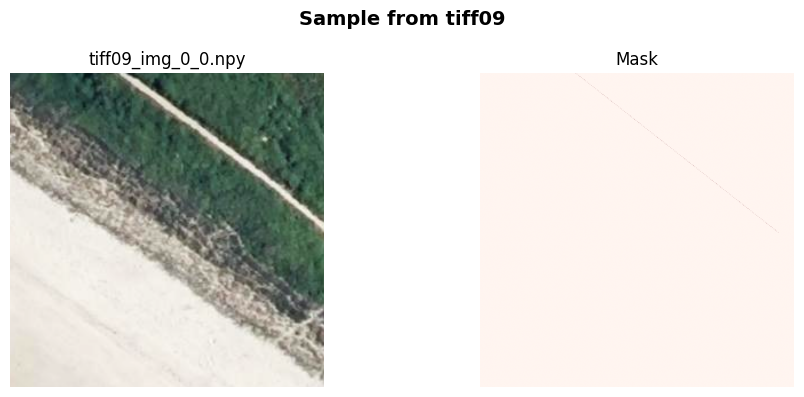


✓ All TIFF files processed and tiles generated!


In [ ]:
# ========================================
# STEP 5: VISUALIZE SAMPLES FROM DIFFERENT TIFFS
# ========================================
from collections import defaultdict
print("\nVisualizing sample tiles from each TIFF...")

# Group tiles by TIFF source
tiles_by_tiff = defaultdict(list)
for img_file in img_files:
    # Extract tiff prefix (e.g., "tiff00" from "tiff00_img_0_0.npy")
    prefix = os.path.basename(img_file).split('_img_')[0]
    tiles_by_tiff[prefix].append(img_file)

# Show one tile from each TIFF
for prefix in sorted(tiles_by_tiff.keys())[:10]:  # Show first 5 TIFFs
    img_file = tiles_by_tiff[prefix][0]
    mask_file = img_file.replace("_img_", "_mask_")

    img = np.load(img_file)
    mask = np.load(mask_file)

    # Convert to (H, W, bands) for display
    if img.shape[0] < img.shape[-1]:
        img = np.moveaxis(img, 0, -1)

    # Normalize for display
    img_disp = img[:, :, :3]
    img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Sample from {prefix}", fontsize=14, fontweight='bold')

    plt.subplot(1, 2, 1)
    plt.imshow(img_disp)
    plt.title(os.path.basename(img_file))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="Reds")
    plt.title("Mask")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

print("\n✓ All TIFF files processed and tiles generated!")

In [ ]:
# ========================================
# STEP 6: CUSTOM DATASET
# ========================================
class TileDataset(Dataset):
    """Custom Dataset that loads tiles from disk on-demand"""

    def __init__(self, img_paths, mask_paths, normalize=True):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.normalize = normalize

        # ImageNet normalization parameters (adapted for 4 channels)
        self.mean = torch.tensor([0.485, 0.456, 0.406, 0.5]).view(4, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225, 0.25]).view(4, 1, 1)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Load from disk only when needed
        img = np.load(self.img_paths[idx])
        mask = np.load(self.mask_paths[idx])

        # Convert to tensors
        img_tensor = torch.tensor(img, dtype=torch.float32)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        # Normalize image
        if self.normalize:
            img_tensor = img_tensor / 255.0
            img_tensor = (img_tensor - self.mean) / self.std

        return img_tensor, mask_tensor

In [ ]:
# ========================================
# STEP 7: SPLIT DATA AND CREATE DATALOADERS
# ========================================
print("\nCreating train/val split...")

# Get file paths (NOT the actual data!)
img_files = sorted(glob.glob(os.path.join(tile_dir, "img_*.npy")))
mask_files = [f.replace("img_", "mask_") for f in img_files]

# Split paths only
img_train, img_val, mask_train, mask_val = train_test_split(
    img_files, mask_files, test_size=0.2, random_state=42
)

print(f"Train tiles: {len(img_train)}")
print(f"Validation tiles: {len(img_val)}")

# Create datasets
train_dataset = TileDataset(img_train, mask_train, normalize=True)
val_dataset = TileDataset(img_val, mask_val, normalize=True)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Test dataloader
print("\nTesting dataloader...")
for images, masks in train_loader:
    print(f"Batch shape: {images.shape}, {masks.shape}")
    print(f"Image range: [{images.min():.2f}, {images.max():.2f}]")
    print(f"Mask range: [{masks.min():.2f}, {masks.max():.2f}]")
    break

In [ ]:
# ========================================
# STEP 8: MODEL SETUP
# ========================================
print("\nSetting up model...")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1,
    activation=None
).to(device)

# Loss functions
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = smp.losses.SoftBCEWithLogitsLoss()


def combined_loss(preds, targets):
    return dice_loss(preds, targets) + bce_loss(preds, targets)


# Optimizer and Learning Rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Metrics
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
f1_metric = BinaryF1Score(threshold=0.5).to(device)

# Learning rate scheduler (optional)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [ ]:
# ========================================
# STEP 9: TRAINING LOOP
# ========================================
print("\nStarting training...")

num_epochs = 5

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        preds = model(images)
        loss = combined_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss, val_iou, val_f1 = 0.0, 0.0, 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)

            loss = combined_loss(preds, masks)
            val_loss += loss.item() * images.size(0)

            preds_sigmoid = torch.sigmoid(preds)
            val_iou += iou_metric(preds_sigmoid, masks.int()
                                  ).item() * images.size(0)
            val_f1 += f1_metric(preds_sigmoid, masks.int()
                                ).item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)
    val_f1 /= len(val_loader.dataset)

    # Learning rate scheduling
    scheduler.step(val_loss)

    print(f"Results: Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | IoU: {val_iou:.4f} | F1: {val_f1:.4f}")

print("\n✓ Training complete!")

# Save model
torch.save(model.state_dict(), "path_segmentation_model.pth")
print("Model saved!")